In [65]:
import pandas as pd
import numpy as np 
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [66]:
data = pd.read_csv('Mall_Customers.csv')
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [67]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [68]:
x=data[['Annual Income (k$)','Spending Score (1-100)']].values

In [69]:
scaler=StandardScaler()
newdata_n=scaler.fit_transform(x)

Apply KMeans clustering.

In [70]:
Kmean=KMeans(n_clusters=5,init='k-means++',random_state=42)
l=Kmean.fit_predict(newdata_n)

Group Clusters in dataframe

In [74]:
data['Kmean_clusters']=l

**Visualize clusters.**

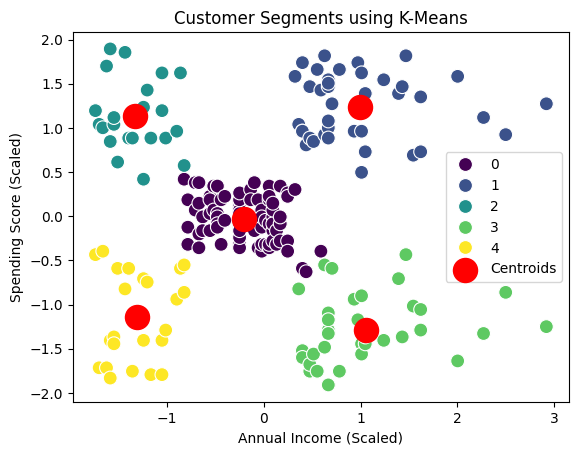

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x=newdata_n[:, 0], y=newdata_n[:, 1], hue=data['Kmean_clusters'], palette='viridis', s=100)
plt.scatter(Kmean.cluster_centers_[:, 0], Kmean.cluster_centers_[:, 1], s=300, c='red', marker='o', label='Centroids')
plt.title('Customer Segments using K-Means')
plt.xlabel('Annual Income (Scaled)')
plt.ylabel('Spending Score (Scaled)')
plt.legend()
plt.show()

# Find optimal K value using elbow method.

In [77]:
wcss=[]
for i in range(1,11):
    Kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    Kmeans.fit(newdata_n)
    wcss.append(Kmeans.inertia_)


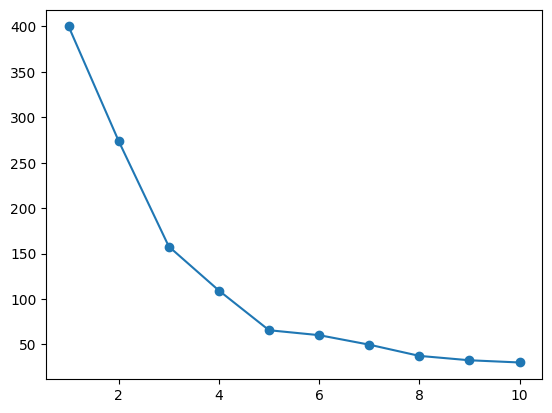

In [80]:
plt.plot(range(1,11),wcss,marker='o')
plt.show()

# Apply DBSCAN clustering.